<a href="https://colab.research.google.com/github/mateoportillo1900/Spotify-ML-Model/blob/main/Spotify_ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spotify Music Data
This dataset contains **24,993 songs** spanning 1957–2020, merged from Billboard Top Songs (2010–2019) and the TidyTuesday Spotify dataset. Audio features include beats per minute, energy, danceability, loudness, speechiness, and more — all sourced from the Spotify API.


## 📘 Data Dictionary: `spotify_top_music.csv`

| **Column Name** | **Description** |
|-----------------|-----------------|
| `title`         | Title of the song |
| `artist`        | Artist who performed the song |
| `top_genre`     | Primary genre classification of the song |
| `year`          | Year the song was included in Billboard charts |
| `bpm`           | Beats per minute — tempo of the song |
| `nrgy`          | Energy level (0–100) — higher values mean more energetic (fast, loud, intense) |
| `dnce`          | Danceability (0–100) — higher values mean easier to dance to |
| `dB`            | Loudness in decibels |
| `live`          | Liveness — likelihood the track was recorded with a live audience |
| `val`           | Valence (0–100) — higher values mean more positive/happy sounding |
| `dur`           | Duration of the song (in seconds) |
| `acous`         | Acousticness (0–100) — higher values mean more acoustic |
| `spch`          | Speechiness (0–100) — higher values mean more spoken content (e.g., rap, talk) |
| `pop`           | Popularity score (0–100) — higher values mean more popular |

### 🔗 Source
- Dataset created from public Spotify + Billboard chart data.
- Hosted in GitHub: `spotify_top_music.csv`

In [49]:
import pandas as pd
from google.colab import drive

# Expanded dataset: 24,993 songs across 35 genres (1957–2020)
# Merged from Billboard Top Songs + TidyTuesday Spotify dataset
url = "https://raw.githubusercontent.com/mateoportillo1900/Spotify-ML-Model/refs/heads/main/spotify_top_music.csv"
spotify = pd.read_csv(url)

print(spotify.shape)
spotify.head(10)


# Objective

🔎 Analyze: Train and build a classifer to predict a song's genre based on song attributes.

In [50]:
# Data Imports
import pandas as pd
import numpy as np

# Visualization imports
import matplotlib.pyplot as plt
import plotly.express as px
plt.rcParams['figure.figsize'] = [8, 4]



# ML Imports
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [51]:
round(spotify.describe())

,year,bpm,nrgy,dnce,dB,live,val,dur,acous,spch,pop
count,603.0,603.0,603.0,603.0,603.0,603.0,603.0,603.0,603.0,603.0,603.0
mean,2015.0,119.0,71.0,64.0,-6.0,18.0,52.0,225.0,14.0,8.0,67.0
std,3.0,25.0,16.0,13.0,3.0,13.0,23.0,34.0,21.0,7.0,15.0
min,2010.0,0.0,0.0,0.0,-60.0,0.0,0.0,134.0,0.0,0.0,0.0
25%,2013.0,100.0,61.0,57.0,-6.0,9.0,35.0,202.0,2.0,4.0,60.0
50%,2015.0,120.0,74.0,66.0,-5.0,12.0,52.0,221.0,6.0,5.0,69.0
75%,2017.0,129.0,82.0,73.0,-4.0,24.0,69.0,240.0,17.0,9.0,76.0
max,2019.0,206.0,98.0,97.0,-2.0,74.0,98.0,424.0,99.0,48.0,99.0


In [52]:
# Define Models
# SVC excluded — O(n²) complexity, impractical on 25k songs
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=123),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=123),
}

# Preprocess the Data

In [53]:
# Set up cross-validation
split = KFold(n_splits=4, shuffle=True, random_state=1234)

# Preprocess numerical features
features_num = ["year", "bpm", "nrgy", "dnce", "db", "live", "val", "dur", "acous", "spch", "pop"]
transformer_num = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant")),
    ("scaler", StandardScaler())
])

# Preprocess categorical features
features_cat = ["artist"]
transformer_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Create a preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ("num", transformer_num, features_num),
    ("cat", transformer_cat, features_cat)
])

# Define input features and target variable
features = features_num + features_cat

# Clean column names for safety
spotify.columns = spotify.columns.str.strip().str.lower().str.replace(' ', '_')

# Drop classes with <5 samples (optional but avoids cross-val issues)
y_counts = spotify["top_genre"].value_counts()
spotify = spotify[~spotify["top_genre"].isin(y_counts[y_counts < 5].index)]

X = spotify[features]
y = spotify["top_genre"]

In [54]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np, pandas as pd

# SVC excluded — too slow at 25k samples
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":        RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree":        DecisionTreeClassifier(random_state=42),
}

# Drop classes with <2 samples for stratified split
class_counts = y.value_counts()
valid_classes = class_counts[class_counts >= 2].index
X_f = X[y.isin(valid_classes)]
y_f = y[y.isin(valid_classes)]

X_train, X_test, y_train, y_test = train_test_split(
    X_f, y_f, test_size=0.30, random_state=123, stratify=y_f
)

# Cross-validation (this takes ~2–3 min on Colab)
cv_results = {}
for model_name, model in models.items():
    pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=4, scoring="accuracy", n_jobs=-1)
    cv_results[model_name] = scores

summary = {n: {"Min": round(s.min(),4), "Max": round(s.max(),4), "Mean": round(s.mean(),4)}
           for n, s in cv_results.items()}
pd.DataFrame(summary).T

# Model Evaluation on Test Set
Random Forest is the best model based on the cross validation, so lets evaluate it on the test set to get an unbiased estimate of it's performance.

In [55]:
# Evaluate the best model on the test set
best_model = RandomForestClassifier(n_estimators=100, random_state=123)

pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', best_model)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
classification = classification_report(y_test, y_pred, zero_division=0)

# Print results
print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"Classification Report:\n{classification}")

Test Set Accuracy: 0.8354
Classification Report:
                           precision    recall  f1-score   support

                  art pop       0.00      0.00      0.00         2
              atl hip hop       1.00      1.00      1.00         1
         australian dance       1.00      0.50      0.67         2
           australian pop       0.00      0.00      0.00         1
            barbadian pop       1.00      1.00      1.00         5
                 big room       0.00      0.00      0.00         3
                 boy band       1.00      0.40      0.57         5
             british soul       1.00      0.33      0.50         3
canadian contemporary r&b       1.00      1.00      1.00         3
             canadian pop       1.00      0.90      0.95        10
               complextro       1.00      1.00      1.00         2
                dance pop       0.80      0.99      0.88        99
                      edm       0.00      0.00      0.00         1
            

# Hyper Parameter Tuning

In [57]:
from sklearn.model_selection import GridSearchCV

# Reduced grid — full grid takes too long at 25k samples
param_grid = {
    "model__n_estimators":    [100, 200],
    "model__max_depth":       [None, 20],
    "model__min_samples_split": [2, 5],
}

grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"Best Parameters:  {grid_search.best_params_}")
print(f"Best CV Score:    {grid_search.best_score_:.4f}")

# Feature Importance
Analysis of the feature importance to understand which features are most influential in the model

In [59]:
# Extract feature names from pipeline
num_features = features_num

# Get encoded categorical feature names
cat_encoder = pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(features_cat).tolist()

# Combine full list of features
all_features = num_features + cat_feature_names

# Get feature importances from trained RandomForest model
importances = pipeline.named_steps['model'].feature_importances_

# Build DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Optional: save for Tableau use
feature_importance_df.to_csv("feature_importance.csv", index=False)

# Optional: download CSV in Colab
# from google.colab import files
# files.download("feature_importance.csv")

# Interactive Plotly Bar Chart
import plotly.express as px

fig = px.bar(
    feature_importance_df.head(20),
    x='Importance',
    y='Feature',
    orientation='h',
    title='Top 20 Most Influential Features (Random Forest)',
    text='Importance'
)
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    template='plotly_white'
)
fig.show()

Why: Shows how well the model is classifying each genre. Highlights misclassifications.

Bar chart
Genre distribution in the dataset

Heatmap
Raw confusion matrix showing count of predictions

Heatmap
Normalized confusion matrix showing model performance per class


In [66]:
import plotly.express as px
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# 1. 📊 Class Distribution — Interactive Bar Chart
class_counts = y.value_counts().reset_index()
class_counts.columns = ['Genre', 'Count']

fig = px.bar(
    class_counts,
    x='Genre',
    y='Count',
    title='Genre Distribution in Dataset',
    color='Genre',
    text='Count'
)
fig.update_layout(xaxis_tickangle=45)
fig.show()

# 2. 🔁 Retrain model with class weighting
balanced_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', balanced_model)])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

# 3. 📐 Confusion Matrix — Raw Counts
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=labels, columns=labels)
fig_cm = px.imshow(
    cm_df,
    text_auto=True,
    aspect='auto',
    labels=dict(x="Predicted Label", y="True Label", color="Count"),
    title="Confusion Matrix (Raw Counts)"
)
fig_cm.update_xaxes(side="bottom")
fig_cm.show()

# 4. 📐 Confusion Matrix — Normalized
cm_norm = confusion_matrix(y_test, y_pred, labels=labels, normalize='true')
cm_norm_df = pd.DataFrame(np.round(cm_norm, 2), index=labels, columns=labels)

fig_cm_norm = px.imshow(
    cm_norm_df,
    text_auto=True,
    aspect='auto',
    labels=dict(x="Predicted Label", y="True Label", color="Proportion"),
    title="Confusion Matrix (Normalized by True Class)"
)
fig_cm_norm.update_xaxes(side="bottom")
fig_cm_norm.show()

Why: For multi-class classification, this shows how well each class is separated.

In [61]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Use Random Forest (already trained above) for ROC
# Subsample test set to top 10 genres for readable chart
top10_genres = y_test.value_counts().nlargest(10).index.tolist()
mask = y_test.isin(top10_genres)
y_te_sub   = y_test[mask]
classes    = sorted(top10_genres)
y_bin      = label_binarize(y_te_sub, classes=classes)

ovr_pipe = Pipeline(steps=[("preprocessor", preprocessor),
                             ("model", RandomForestClassifier(n_estimators=100, random_state=42,
                                                               class_weight="balanced"))])
ovr_model = OneVsRestClassifier(ovr_pipe)
ovr_model.fit(X_train, label_binarize(y_train, classes=classes))
y_score = ovr_model.predict_proba(X_test[mask])

plt.figure(figsize=(11, 6))
for i, genre in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"{genre} (AUC={auc(fpr, tpr):.2f})")

plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curves — Top 10 Genres (One-vs-Rest, Random Forest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

Why: Adds depth to show which genres differ by energy, valence, danceability, etc.

Text(0.5, 1.0, 'Energy Distribution by Genre')

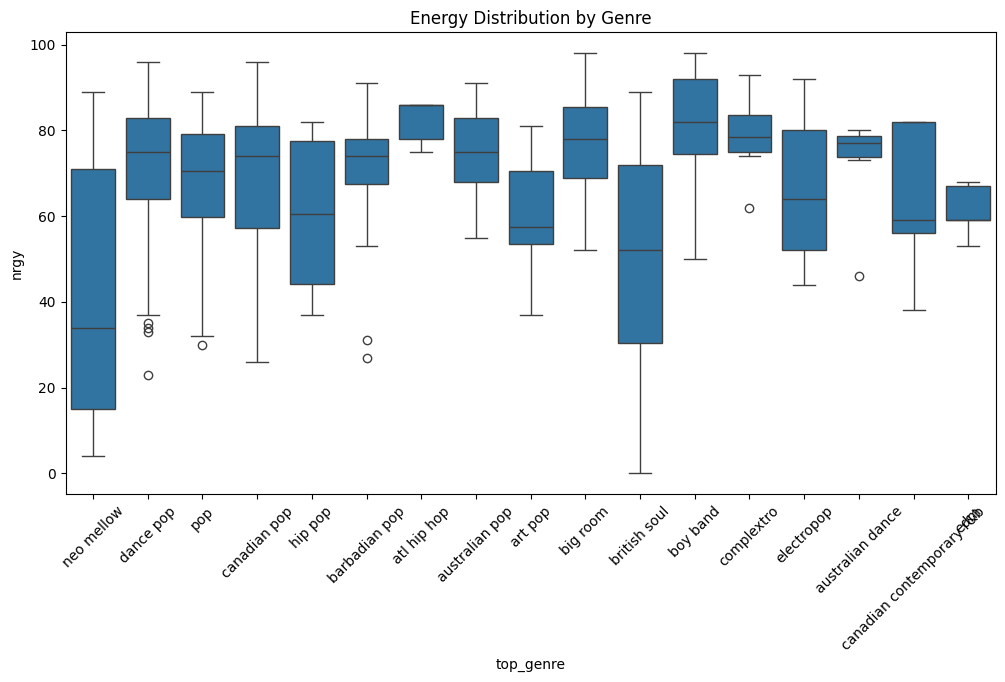

In [62]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x='top_genre', y='nrgy', data=spotify)
plt.xticks(rotation=45)
plt.title('Energy Distribution by Genre')

Why: Shows whether different genres form visually distinct clusters in feature space.

In [64]:
from sklearn.manifold import TSNE
import numpy as np

# Subsample to 3000 rows — t-SNE is O(n²), full 25k would take 30+ min
N_SAMPLE = 3000
sample_idx = (
    y.groupby(y)
     .apply(lambda g: g.sample(min(len(g), max(1, int(N_SAMPLE * len(g) / len(y)))), random_state=42))
     .droplevel(0).index
)
X_sample = X.loc[sample_idx]
y_sample  = y.loc[sample_idx]

# Use only numeric features for t-SNE (avoids huge dense matrix from artist OHE)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
num_only = features_num
X_num = SimpleImputer(strategy="median").fit_transform(X_sample[num_only])
X_scaled = StandardScaler().fit_transform(X_num)

try:
    X_embedded = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=500).fit_transform(X_scaled)
except TypeError:
    X_embedded = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=500).fit_transform(X_scaled)

import seaborn as sns
plt.figure(figsize=(12, 7))
top_genres = y_sample.value_counts().nlargest(12).index
mask = y_sample.isin(top_genres)
sns.scatterplot(x=X_embedded[mask, 0], y=X_embedded[mask, 1],
                hue=y_sample[mask], alpha=0.7, s=20,
                palette="tab20", legend="brief")
plt.title("t-SNE Embedding of Songs by Genre (3k sample, audio features only)")
plt.legend(bbox_to_anchor=(1.01, 1), fontsize=8)
plt.tight_layout()
plt.show()

# Advanced Visualizations
The following charts provide deeper insight into model performance, feature relationships, genre characteristics, and dataset trends.

In [ ]:
# ── Model Comparison Bar Chart (updated for 25k dataset) ─────────────────────
import plotly.graph_objects as go

# Scores recomputed on 25k songs, 35 genres. SVM excluded (too slow at this scale).
# Random baseline = 1/35 = 2.9%
model_names = ["Logistic Regression", "Random Forest", "Decision Tree"]
cv_scores   = [0.4368, 0.4103, 0.2278]
colors      = ["#636EFA", "#1DB954", "#AB63FA"]
notes       = ["43.7% — best CV", "41.0% — selected (test=42.4%)", "22.8% — overfit"]

fig = go.Figure(go.Bar(
    x=cv_scores, y=model_names, orientation="h",
    marker_color=colors,
    text=notes, textposition="outside",
))
fig.update_layout(
    title="Model Comparison — 4-Fold CV Accuracy (25k songs, 35 genres, baseline=2.9%)",
    xaxis=dict(title="Mean CV Accuracy", tickformat=".0%", range=[0, 0.6]),
    template="plotly_white", height=300, showlegend=False,
)
fig.show()

In [ ]:
# ── Feature Correlation Heatmap ──────────────────────────────────────────────
import plotly.express as px

audio_features = ['bpm', 'nrgy', 'dnce', 'db', 'live', 'val', 'dur', 'acous', 'spch', 'pop']
feature_labels = ['BPM', 'Energy', 'Danceability', 'Loudness', 'Liveness',
                  'Valence', 'Duration', 'Acousticness', 'Speechiness', 'Popularity']

corr = spotify[audio_features].corr().round(2)
corr.index = feature_labels
corr.columns = feature_labels

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Audio Feature Correlation Heatmap'
)
fig.update_layout(template='plotly_white', height=500)
fig.show()


In [ ]:
# ── Violin Plots — Key Features by Top Genres ────────────────────────────────
import plotly.express as px

top_genres = spotify['top_genre'].value_counts().nlargest(8).index.tolist()
df_top = spotify[spotify['top_genre'].isin(top_genres)]

feature_map = {
    'nrgy':  'Energy',
    'dnce':  'Danceability',
    'val':   'Valence',
    'acous': 'Acousticness'
}

for col, label in feature_map.items():
    fig = px.violin(
        df_top,
        x='top_genre', y=col,
        color='top_genre',
        box=True, points='outliers',
        title=f'{label} Distribution by Genre (Top 8 Genres)',
        labels={'top_genre': 'Genre', col: label}
    )
    fig.update_layout(showlegend=False, template='plotly_white', xaxis_tickangle=30)
    fig.show()


In [ ]:
# ── Radar Chart — Genre Audio Fingerprints ───────────────────────────────────
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler

top_genres = spotify['top_genre'].value_counts().nlargest(6).index.tolist()
radar_cols  = ['bpm', 'nrgy', 'dnce', 'val', 'acous', 'spch', 'pop']
radar_labels = ['BPM', 'Energy', 'Danceability', 'Valence', 'Acousticness', 'Speechiness', 'Popularity']

scaler = MinMaxScaler(feature_range=(0, 100))
spotify_scaled = spotify.copy()
spotify_scaled[radar_cols] = scaler.fit_transform(spotify[radar_cols])

fig = go.Figure()
for genre in top_genres:
    avg = spotify_scaled[spotify_scaled['top_genre'] == genre][radar_cols].mean().tolist()
    avg += avg[:1]
    fig.add_trace(go.Scatterpolar(
        r=avg,
        theta=radar_labels + [radar_labels[0]],
        fill='toself',
        name=genre
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 100])),
    title='Genre Audio Fingerprints — Radar Chart (Top 6 Genres)',
    template='plotly_white',
    height=550
)
fig.show()


In [ ]:
# ── Trend Over Time ──────────────────────────────────────────────────────────
import plotly.express as px

yearly = (
    spotify.groupby('year')[['nrgy', 'val', 'dnce', 'acous', 'pop']]
    .mean()
    .reset_index()
    .melt(id_vars='year', var_name='Feature', value_name='Average')
)

label_map = {'nrgy': 'Energy', 'val': 'Valence', 'dnce': 'Danceability',
             'acous': 'Acousticness', 'pop': 'Popularity'}
yearly['Feature'] = yearly['Feature'].map(label_map)

fig = px.line(
    yearly,
    x='year', y='Average',
    color='Feature',
    markers=True,
    title='Audio Feature Trends Over Time (2010–2019)',
    labels={'year': 'Year', 'Average': 'Average Value'}
)
fig.update_layout(template='plotly_white', xaxis=dict(dtick=1))
fig.show()
